# Tutorial 2 &mdash; Real-time dynamics with TDVP

The **Time-Dependent Variational Principle** evolves an MPS by projecting the
Schrödinger equation $\,\mathrm i\,\partial_t|\psi\rangle=H|\psi\rangle\,$ onto
the MPS tangent space.  Integrating the projected flow with a Lie&ndash;Trotter
splitting of the site / bond generators gives a sweep that is **exactly
unitary** and **energy conserving** at fixed bond dimension.

Same model and conventions as Tutorial 1,
$$H=-J\sum_i\sigma^x_i\sigma^x_{i+1}-h_x\sum_i\sigma^x_i-h_z\sum_i\sigma^z_i,$$
purely functional, only `ncon` for contractions.

**Roadmap:** ① MPS &rarr; ② MPO &rarr; ③ Observables &rarr; ④ TDVP
(1-site & 2-site) &rarr; ⑤ a global quench &rarr; ⑥ XXZ spin transport
(ballistic vs Anderson-localized).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA
from ncon import ncon

# ---- local operators -------------------------------------------------------
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

## 1&ndash;3. MPS, MPO, Observables

Identical functional core as Tutorial 1 (states, canonical form, the Ising MPO,
and local observables).  Re-defined here so the notebook stands alone.

### Core code &mdash; MPS functions

In [2]:
# ==========================================================================
#  MPS  (functions)
# ==========================================================================
def mps_product(configs):
    """Product-state MPS from a list of single-site vectors (each length d)."""
    return [np.array(c, dtype=complex).reshape(1, len(c), 1) for c in configs]


def mps_all_up(N):
    return mps_product([[1, 0]] * N)


def mps_x_plus(N):
    s = 1 / np.sqrt(2)
    return mps_product([[s, s]] * N)


def mps_random(N, d=2, chi=8, seed=None):
    rng = np.random.default_rng(seed)
    dims = [1] + [min(chi, d ** i, d ** (N - i)) for i in range(1, N)] + [1]
    A = []
    for i in range(N):
        t = (rng.standard_normal((dims[i], d, dims[i + 1]))
             + 1j * rng.standard_normal((dims[i], d, dims[i + 1])))
        A.append(t)
    return right_canonicalize(A)[0]


def bond_dims(A):
    return [t.shape[0] for t in A] + [A[-1].shape[2]]


# ---- gauge / canonical form ----------------------------------------------
def qr_left(A_i):
    """A[l,s,r] -> Q[l,s,m] (left-isometry), R[m,r] with A = Q . R."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl * d, Dr))
    return Q.reshape(Dl, d, -1), R


def qr_right(A_i):
    """A[l,s,r] -> L[l,m], Q[m,s,r] (right-isometry) with A = L . Q."""
    Dl, d, Dr = A_i.shape
    Q, R = LA.qr(A_i.reshape(Dl, d * Dr).conj().T)
    L = R.conj().T
    Qr = Q.conj().T.reshape(-1, d, Dr)
    return L, Qr


def left_canonicalize(A):
    """Sweep left->right with QR; returns (A_left, tail_norm)."""
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(len(A)):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    return A, R  # R is 1x1 scalar = norm


def right_canonicalize(A):
    """Sweep right->left with QR; returns (A_right, head_norm)."""
    A = [t.copy() for t in A]
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    return A, L


def mixed_canonical(A, center):
    """Bring MPS to mixed canonical form with orthogonality centre at `center`.

    Sites < center are left-isometries, sites > center are right-isometries,
    the norm is carried into site `center`.  Returns new list.
    """
    A = [t.copy() for t in A]
    R = np.ones((1, 1), dtype=complex)
    for i in range(center):
        A[i] = ncon([R, A[i]], [[-1, 1], [1, -2, -3]])
        A[i], R = qr_left(A[i])
    A[center] = ncon([R, A[center]], [[-1, 1], [1, -2, -3]])
    L = np.ones((1, 1), dtype=complex)
    for i in reversed(range(center + 1, len(A))):
        A[i] = ncon([A[i], L], [[-1, -2, 1], [1, -3]])
        L, A[i] = qr_right(A[i])
    A[center] = ncon([A[center], L], [[-1, -2, 1], [1, -3]])
    return A


# ---- inner products --------------------------------------------------------
def overlap(bra, ket):
    """<bra|ket> via a left-to-right transfer contraction (ncon)."""
    E = np.ones((1, 1), dtype=complex)
    for B, K in zip(bra, ket):
        E = ncon([E, K, np.conj(B)], [[1, 2], [1, 3, -2], [2, 3, -1]])
    return complex(E[0, 0])


def norm(A):
    return np.sqrt(overlap(A, A).real)


def normalize(A):
    """Return a copy of the MPS rescaled to unit norm."""
    n = norm(A)
    B = [t.copy() for t in A]
    B[0] = B[0] / n
    return B

### Core code &mdash; MPO functions

In [3]:
# ==========================================================================
#  MPO  (functions)
# ==========================================================================
def ising_mpo(N, J=1.0, hx=1.0, hz=0.0):
    """Finite-chain MPO for H = -J sum X X - hx sum X - hz sum Z.

    Bulk tensor W[a,b,s,s'] has bond dim 3.  Boundary vectors select the
    lower-left generation pattern.  Returns a list of N tensors already
    contracted with the boundary vectors at the ends.
    """
    h_on = -hx * X - hz * Z
    W = np.zeros((3, 3, 2, 2), dtype=complex)
    W[0, 0] = I2
    W[1, 0] = X
    W[2, 0] = h_on
    W[2, 1] = -J * X
    W[2, 2] = I2
    vL = np.array([0, 0, 1], dtype=complex)   # start row
    vR = np.array([1, 0, 0], dtype=complex)   # end col
    Ws = []
    for i in range(N):
        if i == 0:
            Ws.append(ncon([vL, W], [[1], [1, -1, -2, -3]]).reshape(1, 3, 2, 2))
        elif i == N - 1:
            Ws.append(ncon([W, vR], [[-1, 1, -2, -3], [1]]).reshape(3, 1, 2, 2))
        else:
            Ws.append(W.copy())
    return Ws


def mpo_expectation(A, W):
    """<psi|H|psi> for (possibly un-normalised) MPS A and MPO W (ncon zipper)."""
    E = np.ones((1, 1, 1), dtype=complex)   # (bra, mpo, ket)
    for Ai, Wi in zip(A, W):
        E = ncon([E, Ai, Wi, np.conj(Ai)],
                 [[1, 2, 3], [3, 5, -3], [2, -2, 4, 5], [1, 4, -1]])
    return complex(E[0, 0, 0])

### Core code &mdash; Observable functions

In [4]:
# ==========================================================================
#  Observables  (functions)
# ==========================================================================
def expectation_1site(A, op, site):
    """<psi|op_site|psi>/<psi|psi> using the mixed-canonical centre."""
    B = mixed_canonical(A, site)
    C = B[site]
    val = ncon([C, op, np.conj(C)], [[1, 2, 3], [4, 2], [1, 4, 3]])
    nrm = ncon([C, np.conj(C)], [[1, 2, 3], [1, 2, 3]])
    return complex(val / nrm).real


def magnetization(A, op=Z):
    return np.array([expectation_1site(A, op, i) for i in range(len(A))])


def correlation(A, opA, opB, i, j):
    """Connected-free two-point <op_i op_j>, i<j, via transfer contraction."""
    if i > j:
        i, j, opA, opB = j, i, opB, opA
    B = mixed_canonical(A, i)
    E = ncon([B[i], opA, np.conj(B[i])], [[1, 2, -2], [3, 2], [1, 3, -1]])
    for k in range(i + 1, j):
        E = ncon([E, B[k], np.conj(B[k])], [[1, 2], [2, 3, -2], [1, 3, -1]])
    E = ncon([E, B[j], opB, np.conj(B[j])],
             [[1, 2], [2, 4, 5], [3, 4], [1, 3, 5]])
    return complex(E).real


def entanglement_entropy(A, bond):
    """Von Neumann entropy across `bond` (between site bond-1 and bond)."""
    center = bond
    B = mixed_canonical(A, center)
    # SVD across the left bond of site `center`
    C = B[center]
    Dl, d, Dr = C.shape
    s = LA.svd(C.reshape(Dl, d * Dr), compute_uv=False)
    p = s ** 2
    p = p / p.sum()
    p = p[p > 1e-16]
    return float(-np.sum(p * np.log(p)))

### Core code &mdash; exact-diagonalization benchmark

In [5]:
# ==========================================================================
#  Exact diagonalization benchmark (dev only)
# ==========================================================================
def ed_ising(N, J=1.0, hx=1.0, hz=0.0):
    def op_at(op, i):
        ops = [I2] * N
        ops[i] = op
        M = ops[0]
        for k in range(1, N):
            M = np.kron(M, ops[k])
        return M
    H = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for i in range(N - 1):
        H -= J * op_at(X, i) @ op_at(X, i + 1)
    for i in range(N):
        H -= hx * op_at(X, i) + hz * op_at(Z, i)
    return H

## 4. TDVP

The engine is a set of **matrix-free effective Hamiltonians** acting on 0-, 1-
and 2-site blocks (`apply_heff0/1/2`) and a small **Krylov exponential**
`lanczos_expmv` that applies $e^{\tau H_{\text{eff}}}$ without ever forming a
dense matrix.

* **1-site TDVP** (`tdvp_step`) evolves each site forward by $e^{-\mathrm i\,dt/2\,H_1}$
  and back-evolves the bond by $e^{+\mathrm i\,dt/2\,H_0}$.  The bond dimension is
  **fixed** &mdash; the state never leaves the manifold it started on.
* **2-site TDVP** (`tdvp2_step`) evolves two-site blocks and SVD-truncates, so the
  bond dimension **grows adaptively** up to $\chi_{\max}$ &mdash; needed when
  starting from a low-entanglement (e.g. product) state.

### Core code &mdash; shared engine (environments, effective $H$, Krylov)

In [6]:
# ==========================================================================
#  Engine  (functions) -- shared kernel: environments, effective H, Krylov
# ==========================================================================
def _expm_herm(Hmat, tau):
    """exp(tau * H) for Hermitian H via eigendecomposition (tau usually -i dt)."""
    w, U = LA.eigh(Hmat)
    return (U * np.exp(tau * w)) @ U.conj().T


def _env_left(FL, A, W):
    return ncon([FL, A, W, np.conj(A)],
                [[1, 2, 3], [3, 5, -3], [2, -2, 4, 5], [1, 4, -1]])


def _env_right(FR, A, W):
    return ncon([A, W, np.conj(A), FR],
                [[-3, 5, 3], [-2, 2, 4, 5], [-1, 4, 1], [1, 2, 3]])


def _build_right_envs(A, W):
    N = len(A)
    FR = [None] * (N + 1)
    FR[N] = np.ones((1, 1, 1), dtype=complex)
    for i in reversed(range(N)):
        FR[i] = _env_right(FR[i + 1], A[i], W[i])
    return FR


# ---- matrix-free effective Hamiltonians (act on a flattened block) --------
def apply_heff1(x, FL, W, FR):
    """H_eff on a 1-site block AC[l,s,r] (flattened)."""
    Dl, d, Dr = FL.shape[2], W.shape[2], FR.shape[2]
    AC = x.reshape(Dl, d, Dr)
    H = ncon([FL, AC, W, FR],
             [[-1, 1, 2], [2, 3, 4], [1, 5, -2, 3], [-3, 5, 4]])
    return H.reshape(-1)


def apply_heff0(x, FL, FR):
    """H_eff on a 0-site (bond) block C[l,r] (flattened)."""
    Dl, Dr = FL.shape[2], FR.shape[2]
    C = x.reshape(Dl, Dr)
    H = ncon([FL, C, FR], [[-1, 1, 2], [2, 3], [-2, 1, 3]])
    return H.reshape(-1)


def apply_heff2(x, FL, W1, W2, FR):
    """H_eff on a 2-site block AAC[l,s1,s2,r] (flattened)."""
    Dl, d1, d2, Dr = FL.shape[2], W1.shape[2], W2.shape[2], FR.shape[2]
    AAC = x.reshape(Dl, d1, d2, Dr)
    H = ncon([FL, AAC, W1, W2, FR],
             [[-1, 1, 2], [2, 3, 4, 5], [1, 6, -2, 3], [6, 7, -3, 4],
              [-4, 7, 5]])
    return H.reshape(-1)


# ---- matrix-free Krylov routines ------------------------------------------
def _lanczos_tridiag(apply, args, v0, k, delta=1e-10):
    """Build an orthonormal Krylov basis and the tridiagonal T (Hermitian)."""
    v0 = np.asarray(v0, dtype=complex)
    krylov, alpha, beta = [], [], []
    vec = v0.copy()
    for it in range(k):
        b = LA.norm(vec)
        if b < delta:
            break
        beta.append(b)
        vec = vec / b
        for w in krylov:                      # full reorthogonalization
            vec = vec - np.vdot(w, vec) * w
        vec = vec / max(LA.norm(vec), 1e-16)
        krylov.append(vec)
        Av = apply(vec, *args)
        alpha.append(np.vdot(vec, Av).real)
        Av = Av - alpha[-1] * krylov[-1]
        if it > 0:
            Av = Av - beta[-1] * krylov[-2]
        vec = Av
    m = len(krylov)
    T = np.diag(alpha).astype(complex)
    if m > 1:
        off = np.array(beta[1:])
        T = T + np.diag(off, 1) + np.diag(off, -1)
    return np.array(krylov), T, beta


def lanczos_ground(apply, args, v0, k=40):
    """Lowest eigenpair (energy, vector) of H_eff via Lanczos."""
    v0 = np.asarray(v0, dtype=complex) / LA.norm(v0)
    Vk, T, _ = _lanczos_tridiag(apply, args, v0, k)
    ev, es = LA.eigh(T)
    gs = Vk.T @ es[:, 0]
    return ev[0], gs / LA.norm(gs)


def lanczos_expmv(apply, args, v0, tau, k=20):
    """Approximate exp(tau * H_eff) v0 in a Krylov subspace (tau complex)."""
    v0 = np.asarray(v0, dtype=complex)
    Z = LA.norm(v0)
    if Z == 0:
        return v0
    Vk, T, _ = _lanczos_tridiag(apply, args, v0 / Z, k)
    c = _expm_herm(T, tau)[:, 0]
    return Z * (Vk.T @ c)

### Core code &mdash; TDVP functions

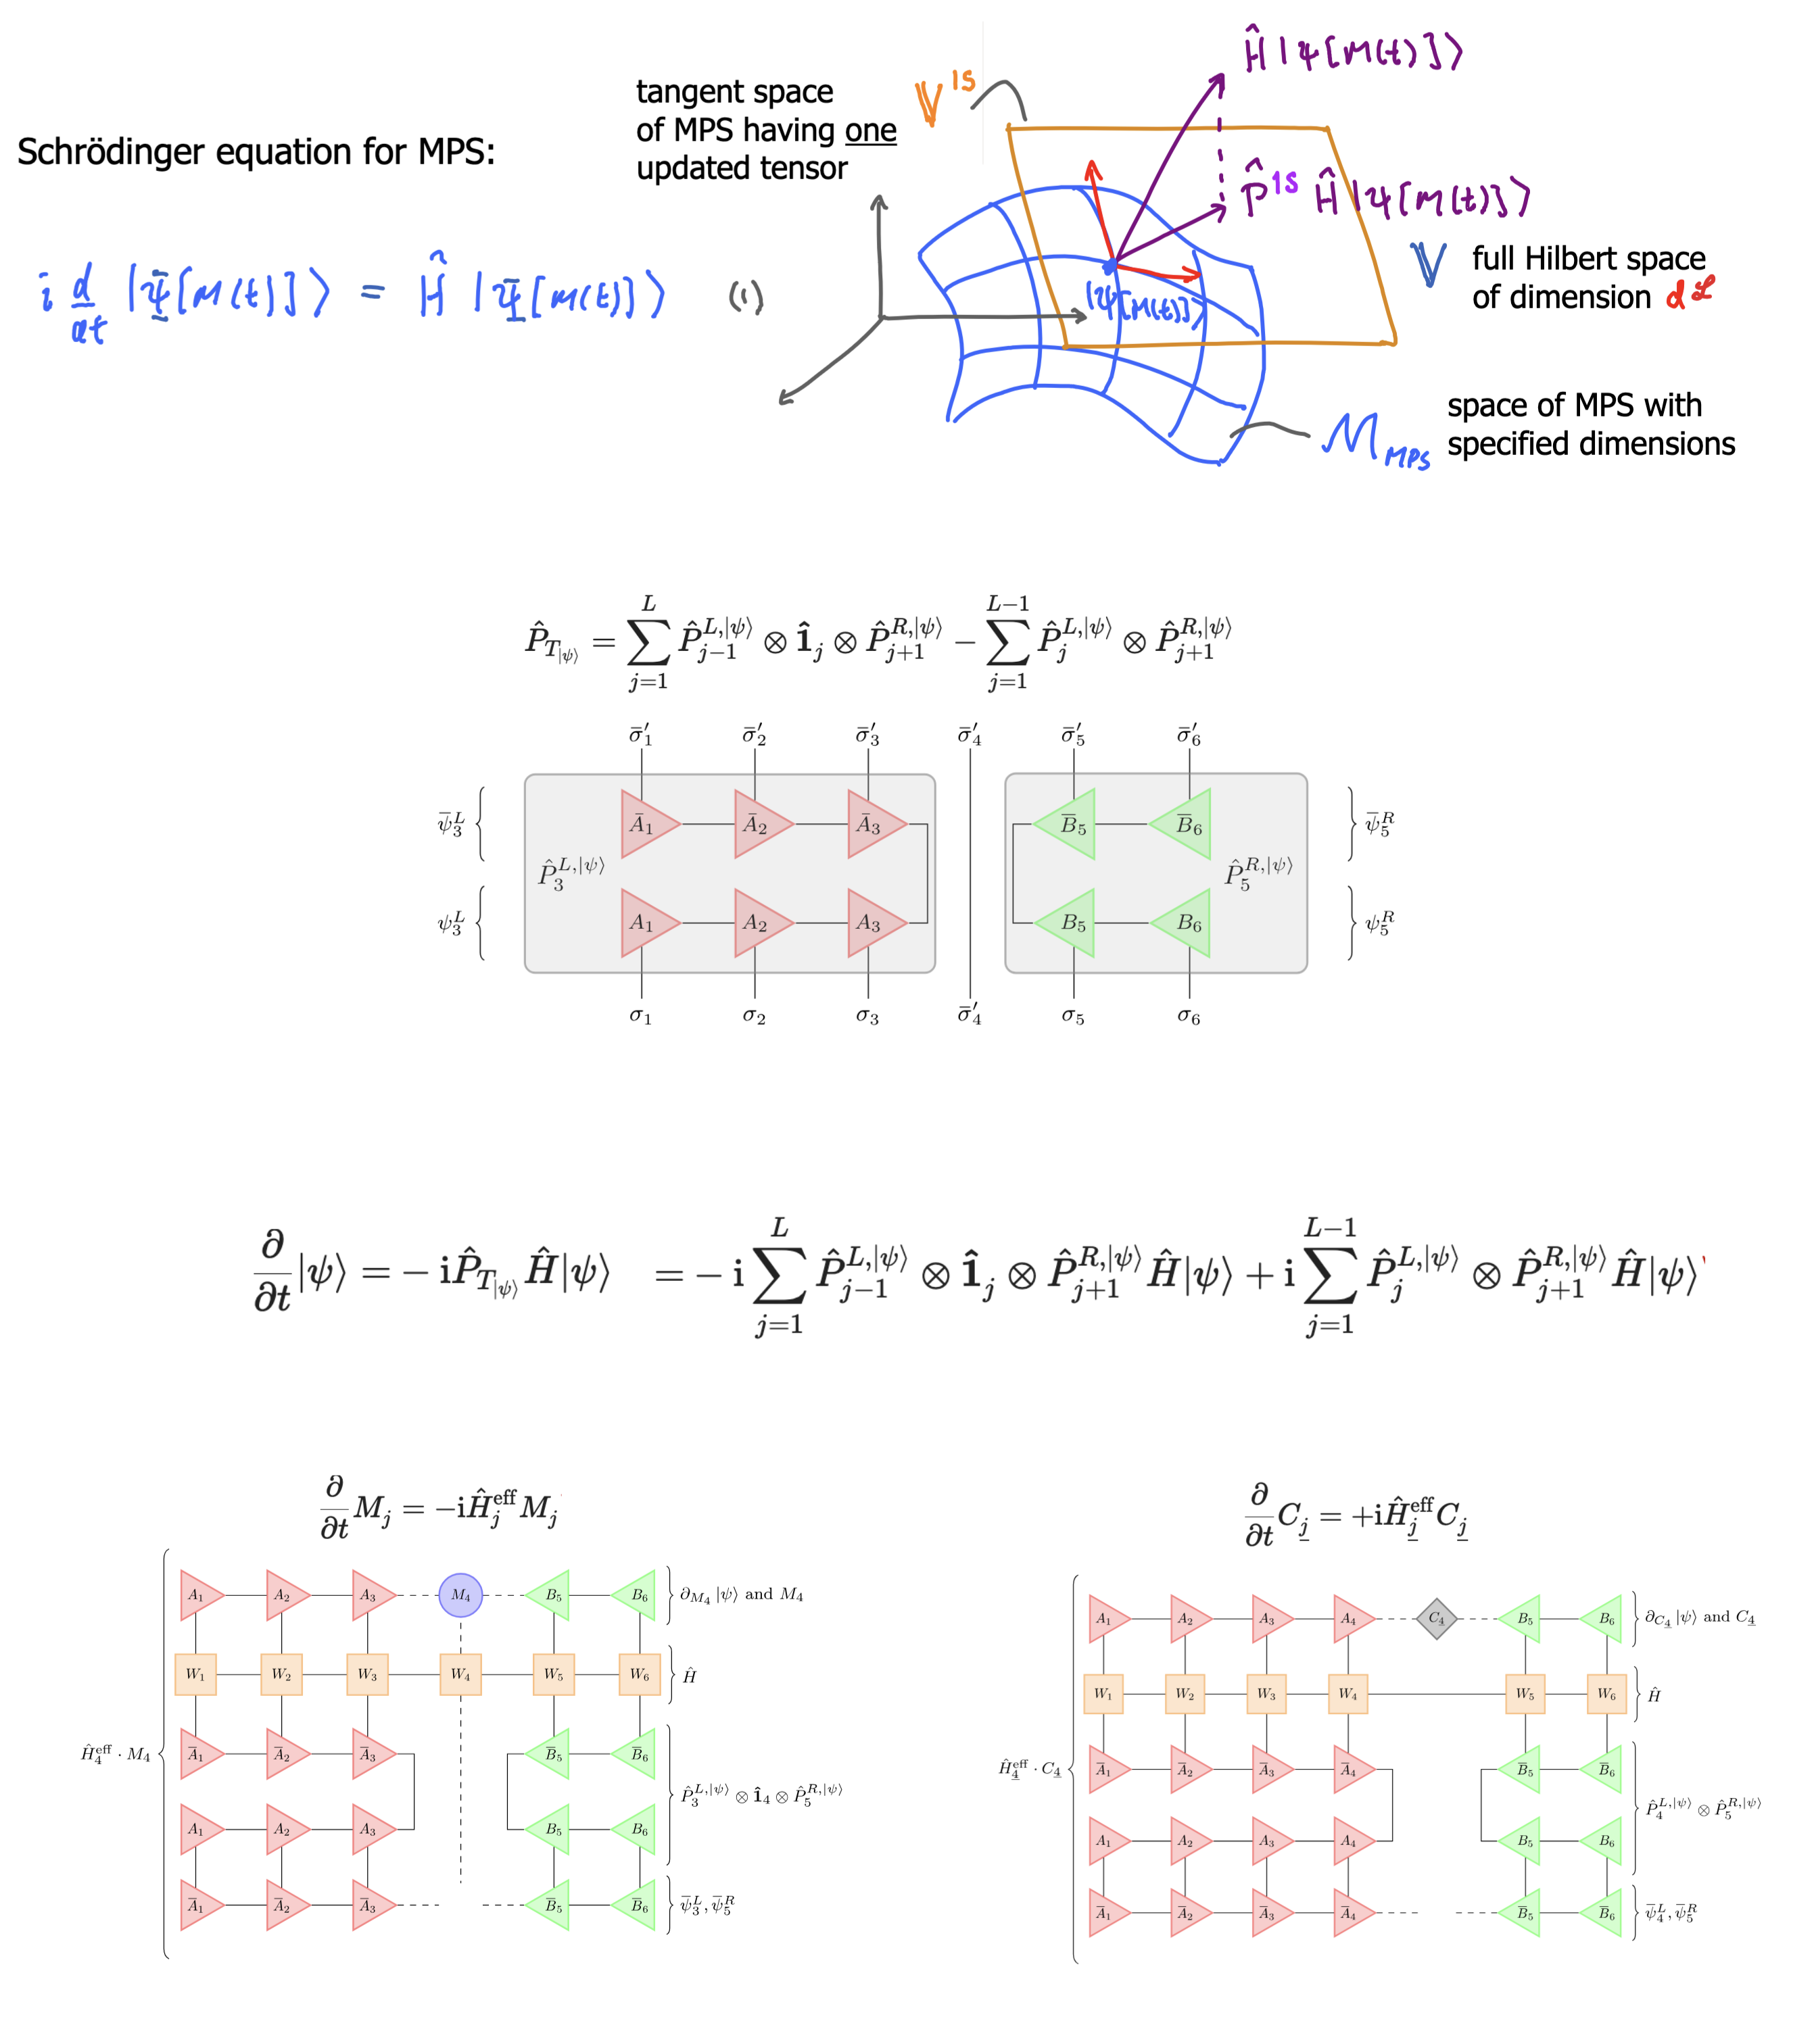

In [19]:
from IPython.display import Image, display
display(Image(filename="TDVP.png", width=1000))

In [7]:
# ==========================================================================
#  TDVP  (functions) -- one-site
# ==========================================================================
def tdvp_step(A, W, dt, krydim=12):
    """One symmetric 1-site TDVP step (right->left then left->right), dt total.

    Fixed bond dimension: the input MPS must be left-canonical and already
    carry the bond dimension one wants (1-site TDVP cannot grow it).  Forward
    site evolution uses exp(-i dt/2 H_1); the intervening bond tensor is
    back-evolved with exp(+i dt/2 H_0).
    """
    N = len(A)
    A = [t.copy() for t in A]
    FL = [None] * (N + 1)
    FR = [None] * (N + 1)
    FL[0] = np.ones((1, 1, 1), dtype=complex)
    for n in range(N):
        FL[n + 1] = _env_left(FL[n], A[n], W[n])
    FR[N] = np.ones((1, 1, 1), dtype=complex)

    # ---- right -> left half sweep ----
    C = np.ones((1, 1), dtype=complex)
    for n in range(N - 1, -1, -1):
        AC = ncon([A[n], C], [[-1, -2, 1], [1, -3]])
        sh = AC.shape
        y = lanczos_expmv(apply_heff1, (FL[n], W[n], FR[n + 1]),
                          AC.reshape(-1), -0.5j * dt, krydim)
        AC = (y / LA.norm(y)).reshape(sh)
        C, AR = qr_right(AC)
        A[n] = AR
        FR[n] = _env_right(FR[n + 1], A[n], W[n])
        if n > 0:
            sc = C.shape
            yc = lanczos_expmv(apply_heff0, (FL[n], FR[n]),
                               C.reshape(-1), +0.5j * dt, krydim)
            C = (yc / LA.norm(yc)).reshape(sc)

    # ---- left -> right half sweep ----
    for n in range(N):
        AC = A[n] if n == 0 else ncon([C, A[n]], [[-1, 1], [1, -2, -3]])
        sh = AC.shape
        y = lanczos_expmv(apply_heff1, (FL[n], W[n], FR[n + 1]),
                          AC.reshape(-1), -0.5j * dt, krydim)
        AC = (y / LA.norm(y)).reshape(sh)
        AL, C = qr_left(AC)
        A[n] = AL
        FL[n + 1] = _env_left(FL[n], A[n], W[n])
        if n < N - 1:
            sc = C.shape
            yc = lanczos_expmv(apply_heff0, (FL[n + 1], FR[n + 1]),
                               C.reshape(-1), +0.5j * dt, krydim)
            C = (yc / LA.norm(yc)).reshape(sc)
    return A


def tdvp2_step(A, W, dt, chi_max=32, krydim=12):
    """One symmetric 2-site TDVP step, dt total.  Bond dimension grows up to
    `chi_max` via SVD truncation, so this works from a product initial state.
    Input and output MPS are left-canonical.
    """
    N = len(A)
    A = [t.copy() for t in A]
    FL = [None] * (N + 1)
    FR = [None] * (N + 1)
    FL[0] = np.ones((1, 1, 1), dtype=complex)
    for n in range(N):
        FL[n + 1] = _env_left(FL[n], A[n], W[n])
    FR[N] = np.ones((1, 1, 1), dtype=complex)

    # ---- right -> left half sweep ----
    AC = A[N - 1]
    for n in range(N - 2, 0, -1):
        AAC = ncon([A[n], AC], [[-1, -2, 1], [1, -3, -4]])
        sh = AAC.shape
        y = lanczos_expmv(apply_heff2, (FL[n], W[n], W[n + 1], FR[n + 2]),
                          AAC.reshape(-1), -0.5j * dt, krydim)
        AAC = (y / LA.norm(y)).reshape(sh)
        AR, AC = _split_right(AAC, chi_max)
        A[n + 1] = AR
        FR[n + 1] = _env_right(FR[n + 2], A[n + 1], W[n + 1])
        yc = lanczos_expmv(apply_heff1, (FL[n], W[n], FR[n + 1]),
                           AC.reshape(-1), +0.5j * dt, krydim)
        AC = (yc / LA.norm(yc)).reshape(AC.shape)

    # ---- turn-around at the left edge: single full-dt step on bond (0,1) ----
    AAC = ncon([A[0], AC], [[-1, -2, 1], [1, -3, -4]])
    sh = AAC.shape
    y = lanczos_expmv(apply_heff2, (FL[0], W[0], W[1], FR[2]),
                      AAC.reshape(-1), -1j * dt, krydim)
    AAC = (y / LA.norm(y)).reshape(sh)
    AL, AC = _split_left(AAC, chi_max)
    A[0] = AL
    FL[1] = _env_left(FL[0], A[0], W[0])

    # ---- left -> right half sweep ----
    for n in range(1, N - 1):
        yc = lanczos_expmv(apply_heff1, (FL[n], W[n], FR[n + 1]),
                           AC.reshape(-1), +0.5j * dt, krydim)
        AC = (yc / LA.norm(yc)).reshape(AC.shape)
        AAC = ncon([AC, A[n + 1]], [[-1, -2, 1], [1, -3, -4]])
        sh = AAC.shape
        y = lanczos_expmv(apply_heff2, (FL[n], W[n], W[n + 1], FR[n + 2]),
                          AAC.reshape(-1), -0.5j * dt, krydim)
        AAC = (y / LA.norm(y)).reshape(sh)
        AL, AC = _split_left(AAC, chi_max)
        A[n] = AL
        FL[n + 1] = _env_left(FL[n], A[n], W[n])

    AL, C = qr_left(AC)                      # fix gauge; drop global scalar
    A[N - 1] = AL
    return A


def _split_left(AAC, chi_max):
    """AAC[l,s1,s2,r] -> (AL[l,s1,m] left-iso, AC[m,s2,r] = S Vh)."""
    Dl, d1, d2, Dr = AAC.shape
    U, S, Vh = LA.svd(AAC.reshape(Dl * d1, d2 * Dr), full_matrices=False)
    chi = max(min(chi_max, int(np.sum(S > 1e-14))), 1)
    U, S, Vh = U[:, :chi], S[:chi] / LA.norm(S[:chi]), Vh[:chi, :]
    return U.reshape(Dl, d1, chi), (np.diag(S) @ Vh).reshape(chi, d2, Dr)


def _split_right(AAC, chi_max):
    """AAC[l,s1,s2,r] -> (AR[m,s2,r] right-iso, AC[l,s1,m] = U S)."""
    Dl, d1, d2, Dr = AAC.shape
    U, S, Vh = LA.svd(AAC.reshape(Dl * d1, d2 * Dr), full_matrices=False)
    chi = max(min(chi_max, int(np.sum(S > 1e-14))), 1)
    U, S, Vh = U[:, :chi], S[:chi] / LA.norm(S[:chi]), Vh[:chi, :]
    return Vh.reshape(chi, d2, Dr), (U @ np.diag(S)).reshape(Dl, d1, chi)

### 1-site TDVP is exact on the full manifold

If the initial MPS already has the maximal bond dimension, the tangent-space
projector is the identity and 1-site TDVP reproduces the exact Schrödinger
evolution.  We check the fidelity against dense time evolution
$e^{-\mathrm i H t}$ on a small chain.

In [8]:
# dense reference evolution e^{-iHt} via eigendecomposition (numpy only)
def dense_propagator(H, t):
    w, V = np.linalg.eigh(H)
    return (V * np.exp(-1j * t * w)) @ V.conj().T

N = 6; J, hx, hz = 1.0, 0.6, 0.8
W = ising_mpo(N, J, hx, hz); H = ed_ising(N, J, hx, hz)

def mps_to_vec(A):
    f = A[0]
    for k in range(1, len(A)):
        f = ncon([f, A[k]], [[-1, -2, 1], [1, -3, -4]]).reshape(1, -1, A[k].shape[2])
    return f.reshape(-1)

A = normalize(left_canonicalize(mps_random(N, chi=8, seed=3))[0])
v = mps_to_vec(A); v /= np.linalg.norm(v)
dt = 0.02; U = dense_propagator(H, dt)
err = 0.0
for _ in range(50):
    A = tdvp_step(A, W, dt)
    v = U @ v
    vt = mps_to_vec(A); vt /= np.linalg.norm(vt)
    err = max(err, abs(1 - abs(np.vdot(vt, v))))
print(f"max |1 - fidelity| over 50 steps (full-rank) = {err:.2e}")

max |1 - fidelity| over 50 steps (full-rank) = 4.22e-15


### 1-site vs 2-site from a product state

Now start from the Néel product state $|\!\uparrow\downarrow\uparrow\downarrow\cdots\rangle$
(bond dimension 1) and quench.  1-site TDVP is *frozen* at $\chi=1$ and gives the
wrong dynamics; 2-site TDVP grows the bond dimension and tracks the exact
result.

In [9]:
N = 8; J, hx, hz = 1.0, 0.6, 0.8
W = ising_mpo(N, J, hx, hz); H = ed_ising(N, J, hx, hz)
psi0 = mps_product([[1, 0] if s % 2 == 0 else [0, 1] for s in range(N)])

def z0_exact(steps, dt):
    v = mps_to_vec(psi0).astype(complex)
    Z0 = np.eye(1)
    ops = [np.eye(2)] * N; ops[0] = Z; M = ops[0]
    for k in range(1, N): M = np.kron(M, ops[k])
    U = dense_propagator(H, dt); out = []
    for _ in range(steps):
        v = U @ v; out.append((v.conj() @ M @ v).real / (v.conj() @ v).real)
    return np.array(out)

dt, steps = 0.05, 60
ex = z0_exact(steps, dt)
A1 = left_canonicalize(psi0)[0]
A2 = left_canonicalize(psi0)[0]
z1, z2, chi2 = [], [], []
for n in range(steps):
    A1 = tdvp_step(A1, W, dt)
    A2 = tdvp2_step(A2, W, dt, chi_max=32)
    z1.append(magnetization(A1, Z)[0])
    z2.append(magnetization(A2, Z)[0])
    chi2.append(max(bond_dims(A2)))
t = dt * np.arange(1, steps + 1)
print(f"2-site TDVP max error vs ED = {np.max(np.abs(np.array(z2)-ex)):.2e}")
print(f"1-site TDVP max error vs ED = {np.max(np.abs(np.array(z1)-ex)):.2e}  (frozen chi=1)")

2-site TDVP max error vs ED = 9.78e-10
1-site TDVP max error vs ED = 9.85e-01  (frozen chi=1)


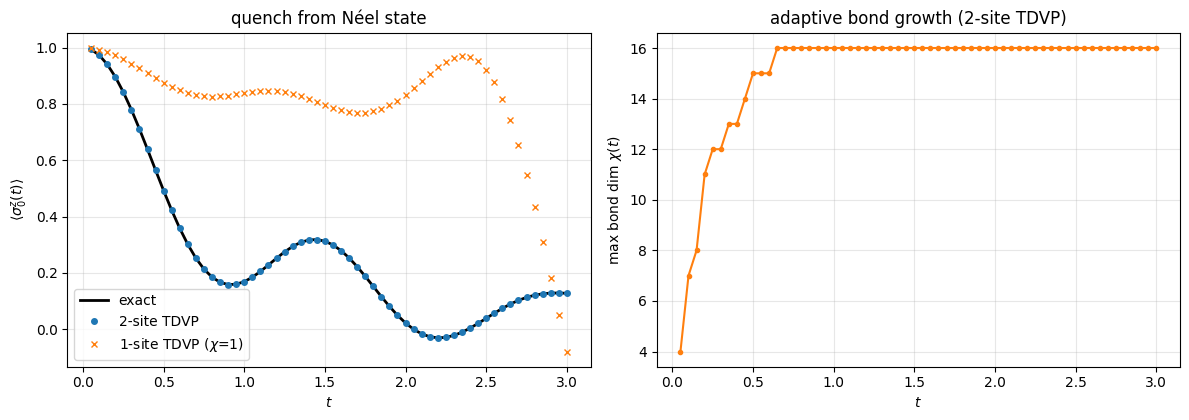

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(t, ex, 'k-', lw=2, label="exact")
ax[0].plot(t, z2, 'o', ms=4, label="2-site TDVP")
ax[0].plot(t, z1, 'x', ms=5, label="1-site TDVP ($\\chi$=1)")
ax[0].set_xlabel("$t$"); ax[0].set_ylabel(r"$\langle\sigma^z_0(t)\rangle$")
ax[0].set_title("quench from Néel state"); ax[0].legend()
ax[1].plot(t, chi2, 'C1.-')
ax[1].set_xlabel("$t$"); ax[1].set_ylabel(r"max bond dim $\chi(t)$")
ax[1].set_title("adaptive bond growth (2-site TDVP)")
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()

In [16]:
N = 32; J, hx, hz = 1.0, 0.6, 0.8
W = ising_mpo(N, J, hx, hz); 
#H = ed_ising(N, J, hx, hz)
psi0 = mps_product([[1, 0] if s % 2 == 0 else [0, 1] for s in range(N)])

dt, steps = 0.05, 60
#ex = z0_exact(steps, dt)
A1 = left_canonicalize(psi0)[0]
A2 = left_canonicalize(psi0)[0]
z1, z2, chi2 = [], [], []
for n in range(steps):
    #A1 = tdvp_step(A1, W, dt)
    A2 = tdvp2_step(A2, W, dt, chi_max=32)
    #z1.append(magnetization(A1, Z)[0])
    z2.append(magnetization(A2, Z)[0])
    chi2.append(max(bond_dims(A2)))
t = dt * np.arange(1, steps + 1)
print(f"2-site TDVP max error vs ED = {np.max(np.abs(np.array(z2)-ex)):.2e}")
#print(f"1-site TDVP max error vs ED = {np.max(np.abs(np.array(z1)-ex)):.2e}  (frozen chi=1)")

2-site TDVP max error vs ED = 1.81e-04


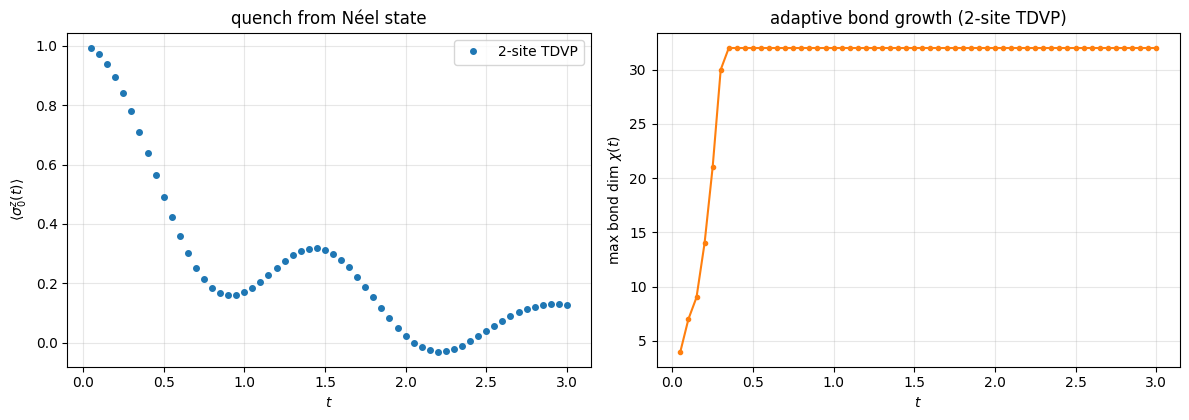

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
#ax[0].plot(t, ex, 'k-', lw=2, label="exact")
ax[0].plot(t, z2, 'o', ms=4, label="2-site TDVP")
#ax[0].plot(t, z1, 'x', ms=5, label="1-site TDVP ($\\chi$=1)")
ax[0].set_xlabel("$t$"); ax[0].set_ylabel(r"$\langle\sigma^z_0(t)\rangle$")
ax[0].set_title("quench from Néel state"); ax[0].legend()
ax[1].plot(t, chi2, 'C1.-')
ax[1].set_xlabel("$t$"); ax[1].set_ylabel(r"max bond dim $\chi(t)$")
ax[1].set_title("adaptive bond growth (2-site TDVP)")
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()

### Energy conservation

A hallmark of TDVP: even with a *finite* bond dimension the projected flow is
symplectic, so the energy is conserved essentially to machine precision along the
whole trajectory (unlike a bare Trotter/TEBD evolution, which has a small
energy drift).

max |E(t) - E(0)| = 8.85e-03


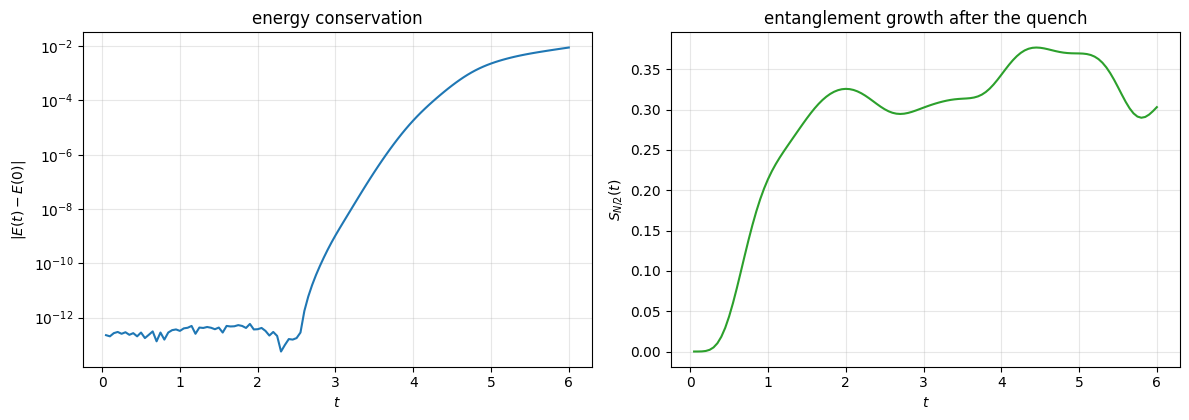

In [18]:
N = 32; J, hx, hz = 1.0, 0.5, 0.9
W = ising_mpo(N, J, hx, hz)
psi0 = mps_x_plus(N)               # x-polarised, then quench with h_z
A = left_canonicalize(psi0)[0]
dt, steps = 0.05, 120
E0 = mpo_expectation(A, W).real
S, tE, drift = [], [], []
for n in range(steps):
    A = tdvp2_step(A, W, dt, chi_max=32)
    E = mpo_expectation(A, W).real / overlap(A, A).real
    drift.append(abs(E - E0)); S.append(entanglement_entropy(A, N // 2))
    tE.append((n + 1) * dt)
print(f"max |E(t) - E(0)| = {max(drift):.2e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].semilogy(tE, drift, 'C0-')
ax[0].set_xlabel("$t$"); ax[0].set_ylabel(r"$|E(t)-E(0)|$")
ax[0].set_title("energy conservation")
ax[1].plot(tE, S, 'C2-')
ax[1].set_xlabel("$t$"); ax[1].set_ylabel(r"$S_{N/2}(t)$")
ax[1].set_title("entanglement growth after the quench")
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()

### Transport in the XXZ chain (Kloss, Bar Lev &amp; Reichman)

We now reproduce the spin-transport study of
[Kloss, Bar Lev &amp; Reichman, arXiv:1710.09378](https://arxiv.org/abs/1710.09378),
which uses 2-site TDVP as a *hydrodynamic* integrator.  Their model is the XXZ
chain (spin operators $S^\alpha=\sigma^\alpha/2$)
$$H=J_{xy}\sum_i\big(S^x_iS^x_{i+1}+S^y_iS^y_{i+1}\big)
   +\Delta\sum_i S^z_iS^z_{i+1}+\sum_i h_i\,S^z_i,\qquad J_{xy}=1,$$
encoded as a **bond-dimension-5 MPO** (the same lower-triangular construction as
the Ising MPO, now carrying $S^x,S^y,S^z$ generators).

The transport observable is the **infinite-temperature spin mean-square
displacement**
$$\sigma^2(t)=\sum_i\Big(\tfrac L2-i\Big)^2\big\langle S^z_i(t)\,S^z_{L/2}(0)\big\rangle_{\beta=0}.$$
The infinite-$T$ average is estimated from **random $S^z$-basis product states**
with a low-variance **antithetic (centre-flip) estimator**: writing the sum over
the centre spin explicitly,
$$\big\langle S^z_i(t)S^z_{L/2}\big\rangle_{\beta=0}
  =\overline{\tfrac14\big(\langle S^z_i(t)\rangle_{c\uparrow}
   -\langle S^z_i(t)\rangle_{c\downarrow}\big)},$$
where the bar averages over the *other* spins and each expectation is a
**product-state quench** $|\psi(t)\rangle=e^{-\mathrm iHt}|\psi_0\rangle$ &mdash;
exactly what 2-site TDVP grows the bond dimension for.  Flipping only the centre
spin cancels the frozen background, so $\sigma^2(0)=0$ *exactly* and a handful of
configurations converge (the paper needs 200&ndash;500 with a naive estimator).
We compare several $\chi_{\max}$ against the exact infinite-$T$ trace on the same
disorder.

In [12]:
# XXZ MPO (bond dim 5) and dense reference; spin operators S = sigma/2
Sx, Sy, Sz = X / 2, Y / 2, Z / 2

def xxz_mpo(N, Jxy=1.0, Delta=0.0, h=None):
    if h is None:
        h = np.zeros(N)
    D = 5
    def bulk(hi):
        W = np.zeros((D, D, 2, 2), dtype=complex)
        W[0, 0] = I2
        W[1, 0] = Sx; W[2, 0] = Sy; W[3, 0] = Sz
        W[4, 0] = hi * Sz
        W[4, 1] = Jxy * Sx; W[4, 2] = Jxy * Sy; W[4, 3] = Delta * Sz
        W[4, 4] = I2
        return W
    vL = np.zeros(D, dtype=complex); vL[4] = 1.0
    vR = np.zeros(D, dtype=complex); vR[0] = 1.0
    Ws = []
    for i in range(N):
        W = bulk(h[i])
        if i == 0:
            Ws.append(ncon([vL, W], [[1], [1, -1, -2, -3]]).reshape(1, D, 2, 2))
        elif i == N - 1:
            Ws.append(ncon([W, vR], [[-1, 1, -2, -3], [1]]).reshape(D, 1, 2, 2))
        else:
            Ws.append(W)
    return Ws

def ed_xxz(N, Jxy=1.0, Delta=0.0, h=None):
    if h is None:
        h = np.zeros(N)
    def op_at(op, i):
        m = np.array([[1.0]], dtype=complex)
        for k in range(N):
            m = np.kron(m, op if k == i else I2)
        return m
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N - 1):
        H += Jxy * (op_at(Sx, i) @ op_at(Sx, i + 1) + op_at(Sy, i) @ op_at(Sy, i + 1))
        H += Delta * (op_at(Sz, i) @ op_at(Sz, i + 1))
    for i in range(N):
        H += h[i] * op_at(Sz, i)
    return H

def sz_diag(L, i):                       # diagonal of S^z_i in the computational basis
    d = np.ones(1)
    for k in range(L):
        d = np.kron(d, np.array([0.5, -0.5]) if k == i else np.array([1.0, 1.0]))
    return d

def sample_configs(L, Wdis, nconf, seed):
    rng = np.random.default_rng(seed)
    cfgs = []
    for _ in range(nconf):
        h = rng.uniform(-Wdis, Wdis, L) if Wdis > 0 else np.zeros(L)
        spins = rng.integers(0, 2, L)     # 0 -> up (S^z=+1/2), 1 -> down
        cfgs.append((h, spins))
    return cfgs

def msd_tdvp(cfgs, L, chi_max, dt, nt, Delta=0.0):
    # Low-variance antithetic estimator: the infinite-T correlator equals an
    # average over the *other* spins of  C_i = (1/4)(<S^z_i>_{c up} - <S^z_i>_{c down}).
    # Flipping only the centre spin cancels the frozen background, so sigma^2(0)=0
    # exactly and a handful of configurations already converge.
    c = L // 2
    weights = (c - np.arange(L)) ** 2
    acc = np.zeros(nt + 1)
    for h, spins in cfgs:
        W = xxz_mpo(L, 1.0, Delta, h)
        prof = np.zeros((nt + 1, L))                 # <S^z_i>_up - <S^z_i>_down
        for sc, sign in ((0, +1), (1, -1)):
            sp = spins.copy(); sp[c] = sc
            A = left_canonicalize(mps_product([[1, 0] if s == 0 else [0, 1] for s in sp]))[0]
            prof[0] += sign * 0.5 * magnetization(A, Z)
            for n in range(nt):
                A = tdvp2_step(A, W, dt, chi_max=chi_max)
                prof[n + 1] += sign * 0.5 * magnetization(A, Z)
        acc += 0.25 * (prof @ weights)
    return dt * np.arange(nt + 1), acc / len(cfgs)

def msd_exact(cfgs, L, dt, nt, Delta=0.0):
    # Exact infinite-T MSD with no spin sampling:
    #   sigma^2(t) = Tr[ e^{iHt} Wop e^{-iHt} S^z_c ] / 2^L,   Wop = sum_i (c-i)^2 S^z_i,
    # evaluated in the eigenbasis (H = V diag(w) V^dagger); disorder is still averaged.
    c = L // 2
    times = dt * np.arange(nt + 1)
    Wop = sum((c - i) ** 2 * sz_diag(L, i) for i in range(L))
    Scd = sz_diag(L, c)
    acc = np.zeros(nt + 1)
    for h, spins in cfgs:
        w, V = np.linalg.eigh(ed_xxz(L, 1.0, Delta, h))
        M = (V.conj().T * Wop) @ V
        Ncd = (V.conj().T * Scd) @ V
        coeff = M * Ncd.T                            # coeff[a,b] = M_ab * N_ba
        wab = w[:, None] - w[None, :]
        for n in range(nt + 1):
            acc[n] += np.real(np.sum(coeff * np.exp(1j * wab * times[n]))) / 2 ** L
    return times, acc / len(cfgs)

#### Figure 1 (upper panel): clean XX chain &mdash; ballistic transport

At $\Delta=0,\,W=0$ the XX chain maps to free fermions, so the MSD grows
**ballistically**, $\sigma^2(t)\propto t^2$.  On a finite chain the growth bends
over once the wavefront reaches the boundary; before that, every $\chi_{\max}$
tracks the exact free-fermion result.

clean XX: sigma^2 grows to 2.68 at t=4.8


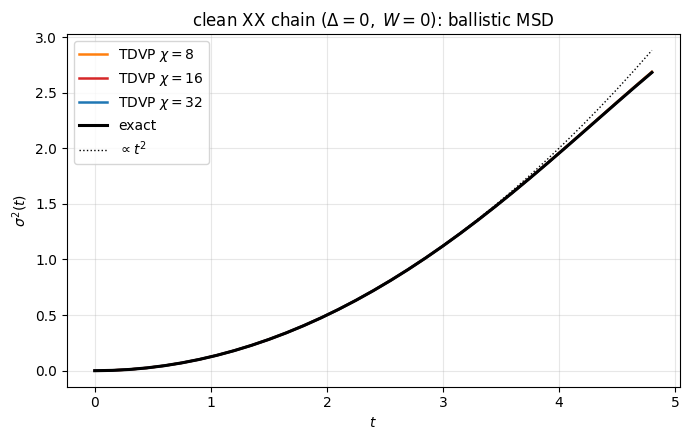

In [13]:
L, dt, nt = 8, 0.15, 32
cfgs = sample_configs(L, Wdis=0.0, nconf=8, seed=1)
t, msd_ex = msd_exact(cfgs, L, dt, nt)
curves = {chi: msd_tdvp(cfgs, L, chi, dt, nt)[1] for chi in (8, 16, 32)}
print(f"clean XX: sigma^2 grows to {msd_ex[-1]:.2f} at t={t[-1]:.1f}")

plt.figure(figsize=(7, 4.5))
for chi, sh in zip((8, 16, 32), ("C1", "C3", "C0")):
    plt.plot(t, curves[chi], color=sh, lw=1.8, label=fr"TDVP $\chi={chi}$")
plt.plot(t, msd_ex, 'k-', lw=2.2, label="exact")
plt.plot(t, msd_ex[1] * (t / t[1]) ** 2, 'k:', lw=1, label=r"$\propto t^2$")
plt.xlabel("$t$"); plt.ylabel(r"$\sigma^2(t)$")
plt.title("clean XX chain ($\\Delta=0,\\;W=0$): ballistic MSD")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

#### Figure 2 (upper panel): disordered XX chain &mdash; Anderson localization

Adding a random field $h_i\in[-W,W]$ with $W=1$ (still $\Delta=0$, non-interacting)
Anderson-localizes every single-particle mode.  The MSD now **saturates**: the
excitation stays trapped near the centre and $\sigma^2(t)\to$ const.  TDVP tracks
the exact saturation while the largest $\chi_{\max}$ stays converged longest.

disordered XX (W=1): sigma^2 saturates near 1.53


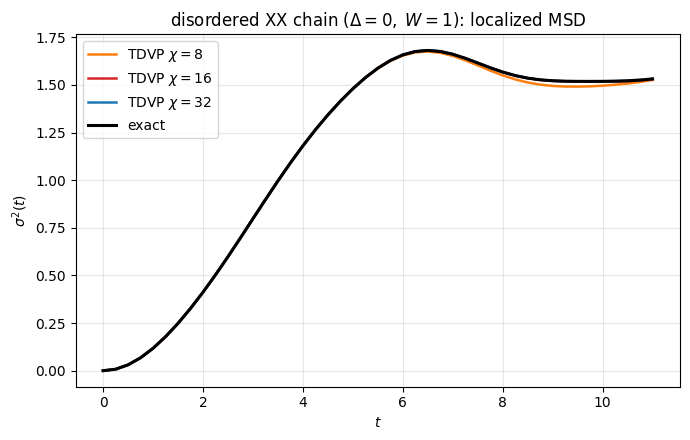

In [14]:
L, dt, nt = 10, 0.25, 44
cfgs = sample_configs(L, Wdis=1.0, nconf=10, seed=7)
t, msd_ex = msd_exact(cfgs, L, dt, nt)
curves = {chi: msd_tdvp(cfgs, L, chi, dt, nt)[1] for chi in (8, 16, 32)}
print(f"disordered XX (W=1): sigma^2 saturates near {msd_ex[-1]:.2f}")

plt.figure(figsize=(7, 4.5))
for chi, sh in zip((8, 16, 32), ("C1", "C3", "C0")):
    plt.plot(t, curves[chi], color=sh, lw=1.8, label=fr"TDVP $\chi={chi}$")
plt.plot(t, msd_ex, 'k-', lw=2.2, label="exact")
plt.xlabel("$t$"); plt.ylabel(r"$\sigma^2(t)$")
plt.title("disordered XX chain ($\\Delta=0,\\;W=1$): localized MSD")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Summary

* TDVP integrates the Schrödinger equation **inside the MPS manifold** via a
  Trotter split of site (`apply_heff1`) and bond (`apply_heff0`) generators,
  applied with a matrix-free **Krylov exponential**.
* **1-site TDVP** keeps $\chi$ fixed &mdash; exact on the full manifold, but frozen
  if the initial state is under-entangled.
* **2-site TDVP** grows $\chi$ by SVD truncation and reproduces exact quench
  dynamics from a product state.
* TDVP **conserves energy** to machine precision, its defining advantage over bare
  Trotter time evolution.
* As a **hydrodynamic integrator** (Kloss&ndash;Bar Lev&ndash;Reichman) 2-site TDVP
  reproduces the infinite-temperature spin MSD of the XXZ chain: **ballistic**
  $\sigma^2\!\propto\!t^2$ in the clean XX limit, and **saturating** (Anderson
  localized) once a random field is switched on.